In [1]:
anthropic_key = "REDACTED_API_KEY"
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("ANTHROPIC_API_KEY")

In [43]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_ollama import ChatOllama
from IPython.display import Image, display
from typing import Dict, TypedDict, Optional
import random
import time
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM
import json
import random

In [144]:
# Prompt Path Values
PROMPTS_ROOT_DIR = "prompts"
AIAH_CONSCIENCE_MANAGER_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/AIAH_conscience_manager.json"
AIAH_SKILL_MANAGER_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/AIAH_skill_manager.json"
AIAH_MEMORY_MANAGER_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/AIAH_memory_manager.json"
AIAH_HEALTH_MANAGER_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/AIAH_health_manager.json"
AIAH_GET_ACTION_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/AIAH_get_action_prompt.json"
ES_GET_ENV_STATUS_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/ES_get_environment_status.json"
ES_UPDATE_ENV_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/ES_update_environment.json"
REALITY_CHECK_AGENT_PROMPT_PATH = f"{PROMPTS_ROOT_DIR}/reality_check_agent.json"
# Data Path Values
STATE_NOTES_ROOT_DIR = "state_notes"
AIAH_CONSCIENCE_DATA_PATH = f"{STATE_NOTES_ROOT_DIR}/AIAH_conscience.json"
AIAH_SKILL_DATA_PATH = f"{STATE_NOTES_ROOT_DIR}/AIAH_skills.json"
AIAH_MEMORY_DATA_PATH = f"{STATE_NOTES_ROOT_DIR}/AIAH_memory.json"
AIAH_HEALTH_DATA_PATH = f"{STATE_NOTES_ROOT_DIR}/AIAH_health.json"
ENVIRONMENT_DATA_PATH = f"{STATE_NOTES_ROOT_DIR}/ES_notes.json"
# Agent Names
ENVIRONMENT_SIMULATOR_DAY_START_AGENT_NAME = "ENVIRONMENT_SIMULATOR_DAY_START"
ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME = "ENVIRONMENT_SIMULATOR_DAY_END"
AI_AS_HUMAN_AGENT_NAME = "AIAH_AGENT"
REALITY_CHECK_AGENT_NAME = "REALITY_CHECK_AGENT"
AIAH_CONSCIENCE_MANAGER_NAME = "AIAH_CONSCIENCE_MANAGER"
AIAH_SKILL_MANAGER_NAME = "AIAH_SKILL_MANAGER"
AIAH_MEMORY_MANAGER_NAME = "AIAH_MEMORY_MANAGER"
AIAH_HEALTH_MANAGER_NAME = "AIAH_HEALTH_MANAGER"
# Other Variables
MAX_RETRIES_WITH_AIAH_AGENT = 3

class EnvironmentGraphState(TypedDict):
    """
    State Graph for the Environment Simulation. 
    A State Contatins the Following information: 
    
    - previous_agent: the agent prompted/used before this
    - current_agent: the current agent to be used
    - metadata: json data carried from the previous agent
    - day_count: day of experiment (will be used to interrupt and select new flows)
    - luck_factor: luck of the agent in the day (decided by the environment)
    """
    previous_agent: Optional[str] = None
    current_agent: Optional[str] = None
    state_metadata: Optional[dict] = {}
    simulation_day_count: Optional[int] = 1
    day_luck_factor: Optional[float] = None
    simulation_total_days = 5
    

In [ ]:
def  display_prompt_metadata(prompt_data):
    print(f"Prompt Metadata:")
    for key in prompt_data["metadata"]:
        print(f"- {key}: {prompt_data["metadata"][key]}")
    
def prompt_llm(system_prompt,user_input,model="llama",verbose=False):
    """
    Supporting function to prompt LLM
    """
    if len(system_prompt)==0:
        raise Exception("Invalid System Prompt - Empty")
    if len(user_input)==0:
        raise Exception("Invalid User Input - Empty")
    if model == "llama":
        # code to prompt Ollama
        if verbose:
            print("Prompting Llama")
        return {"environment_status":"environment_status",
                "action":"action",
                "updated_health":{},
                "environment_status":{},
                "prompt":"prompt",
                "possibility":True,
                "reasoning":"reasoning",
                "updated_environment_status": {},
                "notes_for_next_state": {},
                "updated_conscience":{},
                "updated_skills":{},
                "updated_memory":{}
                }
    elif model == "gpt-4o":
        # code to prompt gpt4-o
        if verbose:
            print("Prompting GPT")
        return {"environment_status":"environment_status",
                "action":"action",
                "updated_health":{},
                "environment_status":{},
                "prompt":"prompt",
                "possibility":True,
                "reasoning":"reasoning",
                "updated_environment_status": {},
                "notes_for_next_state": {},
                "updated_conscience":{},
                "updated_skills":{},
                "updated_memory":{}
                }
    else:
        raise Exception(f"No Support for model {model}. Add code in function prompt_llm")
        
        
def AIAH_diary_dropout(health,conscience,skills,memory):
    """
    Dropout-like behaviour for agent memory, based on health
    """
    health_values = [val for key,val in health.items() if key != "body_temperature"]
    average_value = round(sum(health_values)/len(health_values),2)
    p = average_value/10 # as a fraction, all values are between 1 and 10
    conscience = random.sample(conscience, int(len(conscience)*p))
    skills = random.sample(skills, int(len(skills)*p))
    memory = random.sample(memory, int(len(memory)*p))
    diary = {
        "conscience":conscience,
        "skills":skills,
        "memory":memory
    }
    return diary


def handle_ES_environment_status(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to handle ES get environment status action
    """
    prompt_data = json.load(open(ES_GET_ENV_STATUS_PROMPT_PATH))
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    simulation_day_number = state['simulation_day_count']
    prompt_supporting_metadata = {
        "current_day": simulation_day_number,
        "luck_factor": state['day_luck_factor'],
        "previous_environment_notes": state['state_metadata'].get("Day_Environment_Post_Action",{}) # basically, environment update from previous iteration
    }
    user_input = json.dumps(prompt_supporting_metadata)
    
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    
    # process response, update Environment notes
    environment_notes_day = llm_response["environment_status"] # needs to be dictionary
    aiah_prompt = llm_response["prompt"]
    
    state['state_metadata']["AIAH_prompt_from_ES"] = aiah_prompt
    state['state_metadata']["Day_Environment_Pre_Action"] = environment_notes_day
    state['previous_agent'] = ENVIRONMENT_SIMULATOR_DAY_START_AGENT_NAME
    state['current_agent'] = None # resent current agent name for state_manager
    
    environment_notes = json.load(open(ENVIRONMENT_DATA_PATH))
    environment_notes["data"].append({
        "day":simulation_day_number,
        "notes": [
            environment_notes_day
        ]
    })
    json.dump(environment_notes,open(ENVIRONMENT_DATA_PATH,"w"))
    return state

def handle_AIAH_get_action(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to handle AIAH get action
    """
    prompt_data = json.load(open(AIAH_GET_ACTION_PROMPT_PATH))
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    simulation_day_number = state['simulation_day_count']
    current_agent_health = json.load(open(AIAH_HEALTH_DATA_PATH))
    agent_conscience = json.load(open(AIAH_CONSCIENCE_DATA_PATH))
    agent_skills = json.load(open(AIAH_SKILL_DATA_PATH))
    agent_memory = json.load(open(AIAH_MEMORY_DATA_PATH))
    agent_diary = AIAH_diary_dropout(current_agent_health["data"],agent_conscience["data"],agent_skills["data"],agent_memory["data"])

    prompt_supporting_metadata = {
        "day": simulation_day_number,
        "environment_update": state['state_metadata']["Day_Environment_Before_Action"], # can include ES prompt to Human
        "agent_status":current_agent_health["data"],
        "diary":agent_diary
    }
    user_input = json.dumps(prompt_supporting_metadata)
    
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    
    # processing llm response
    agent_action_reasoning = llm_response["action"]
    
    state['previous_agent'] = AI_AS_HUMAN_AGENT_NAME
    state['current_agent'] = None
    state['state_metadata']["AIAH_Day_Action"] = agent_action_reasoning
    
    return state


def handle_reality_check_agent(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to get feasibility of an action performed by an AIAH given the environment
    """
    prompt_data = json.load(open(REALITY_CHECK_AGENT_PROMPT_PATH))
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    simulation_day_number = state['simulation_day_count']
    current_agent_health = json.load(open(AIAH_HEALTH_DATA_PATH))
    environment_status_notes = json.load(open(ENVIRONMENT_DATA_PATH))
    environment_day_status = environment_status_notes["data"][-1]
    # check to ensure things are going good. 
    assert environment_day_status["day"]==simulation_day_number
    agent_action_taken = state['state_metadata']["AIAH_Day_Action"]

    prompt_supporting_metadata = {
        "environment_status" : environment_day_status, # can include ES prompt to Human
        "current_health" : current_agent_health["data"],
        "action_taken" : agent_action_taken
    }
    
    user_input = json.dumps(prompt_supporting_metadata)
    
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    
    # processing llm response
    state['state_metadata']["AIAH_Day_Action_Possibility"] = llm_response["possibility"]
    state['state_metadata']["Reality_Check_Agent_Reasoning"] = llm_response["reasoning"]
    state['previous_agent'] = REALITY_CHECK_AGENT_NAME
    state['current_agent'] = None
    
    return state


def handle_ES_get_environment_update(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to get environment update from ES, after AIAH Action is feasible
    """
    prompt_data = json.load(open(ES_UPDATE_ENV_PROMPT_PATH))
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    simulation_day_number = state['simulation_day_count']
    environment_status_notes = json.load(open(ENVIRONMENT_DATA_PATH))
    environment_day_status = environment_status_notes["data"][-1]
    # check to ensure things are going good. 
    past_environment_notes = environment_status_notes["data"][-10:] #limiting to past 10
    assert environment_day_status["day"]==simulation_day_number
    agent_action_taken = state['state_metadata']["AIAH_Day_Action"]
    assert state['state_metadata']["AIAH_Day_Action_Possibiliy"] == True

    prompt_supporting_metadata = {
        "environment_status" : environment_day_status, # can include ES prompt to Human
        "action_taken" : agent_action_taken,
        "luck_factor" : state['day_luck_factor'],
        "previous_environment_notes" : past_environment_notes
    }
    
    user_input = json.dumps(prompt_supporting_metadata)
    
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    state['previous_agent'] = ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME
    state['current_agent'] = None
    
    # processing llm response
    state['state_metadata']["Day_Environment_Post_Action"] = llm_response["updated_environment_status"]
    future_notes = llm_response["notes_for_next_state"]
    
    updated_env = llm_response["updated_environment_status"]
    updated_env["notes_for_future"] = llm_response["notes_for_next_state"]
    environment_notes = json.load(open(ENVIRONMENT_DATA_PATH))
    # hoping assertion passed before:
    environment_notes["data"][-1]["notes"].append(updated_env)
    json.dump(environment_notes,open(ENVIRONMENT_DATA_PATH,'w'))
    
    return state  

def handle_conscience_manager_get_notes(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to handle Conscience Manager
    """
    prompt_data = json.load(AIAH_CONSCIENCE_MANAGER_PROMPT_PATH)
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    simulation_day_number = state['simulation_day_count']
    aiah_conscience_notes = json.load(AIAH_CONSCIENCE_DATA_PATH)
    agent_health_data = json.load(AIAH_HEALTH_DATA_PATH)
    environment_day_status = state['state_metadata']["Day_Environment_Pre_Action"]
    environment_day_update = state['state_metadata']["Day_Environment_Post_Action"]
    # check to ensure things are going good. 
    agent_action_taken = state['state_metadata']["AIAH_Day_Action"]
    assert state['state_metadata']["AIAH_Day_Action_Possibiliy"] == True

    prompt_supporting_metadata = {
        "environment_status" : environment_day_status, # can include ES prompt to Human
        "action_taken" : agent_action_taken,
        "current_health": agent_health_data["data"],
        "environment_outcome" : environment_day_update,
        "previous_conscience_notes" : aiah_conscience_notes["data"]
    }
    
    user_input = json.dumps(prompt_supporting_metadata)
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    state['previous_agent'] = AIAH_CONSCIENCE_MANAGER_NAME
    state['current_agent'] = None
    
    # processing llm response
    updated_conscience_addition = llm_response["updated_conscience_notes"]
    state['state_metadata']["AIAH_Conscience_Update"] = updated_conscience_addition
    aiah_conscience_notes["data"].append(updated_conscience_addition)
    json.dumps(aiah_conscience_notes,AIAH_CONSCIENCE_DATA_PATH)
    
    return state

def handle_memory_manager_get_notes(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to handle Memory Manager
    """
    prompt_data = json.load(open(AIAH_MEMORY_MANAGER_PROMPT_PATH))
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    aiah_memory_notes = json.load(open(AIAH_MEMORY_DATA_PATH))
    agent_health_data = json.load(open(AIAH_HEALTH_DATA_PATH))
    environment_day_status = state['state_metadata']["Day_Environment_Pre_Action"]
    environment_day_update = state['state_metadata']["Day_Environment_Post_Action"]
    # check to ensure things are going good. 
    agent_action_taken = state['state_metadata']["AIAH_Day_Action"]

    prompt_supporting_metadata = {
        "environment_status" : environment_day_status, # can include ES prompt to Human
        "action_taken" : agent_action_taken,
        "current_health": agent_health_data["data"],
        "environment_outcome" : environment_day_update,
        "previous_memories" : aiah_memory_notes["data"]
    }
    
    user_input = json.dumps(prompt_supporting_metadata)
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    state['previous_agent'] = AIAH_MEMORY_MANAGER_NAME
    state['current_agent'] = None
    
    # processing llm response
    updated_memory_addition = llm_response["updated_memories"]
    state['state_metadata']["AIAH_Memory_Update"] = updated_memory_addition
    aiah_memory_notes["data"].append(updated_memory_addition)
    json.dump(aiah_memory_notes,open(AIAH_MEMORY_DATA_PATH,"w"))
    
    return state

def handle_skill_manager_get_notes(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to handle Skill Manager
    """
    prompt_data = json.load(open(AIAH_SKILL_MANAGER_PROMPT_PATH))
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    aiah_skill_notes = json.load(open(AIAH_SKILL_DATA_PATH))
    agent_health_data = json.load(open(AIAH_HEALTH_DATA_PATH))
    environment_day_status = state['state_metadata']["Day_Environment_Pre_Action"]
    environment_day_update = state['state_metadata']["Day_Environment_Post_Action"]
    # check to ensure things are going good. 
    agent_action_taken = state['state_metadata']["AIAH_Day_Action"]

    prompt_supporting_metadata = {
        "environment_status" : environment_day_status, # can include ES prompt to Human
        "action_taken" : agent_action_taken,
        "current_health": agent_health_data["data"],
        "environment_outcome" : environment_day_update,
        "previous_skills" : aiah_skill_notes["data"]
    }
    
    user_input = json.dumps(prompt_supporting_metadata)
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    state['previous_agent'] = AIAH_SKILL_MANAGER_NAME
    state['current_agent'] = None
    
    # processing llm response
    updated_skill_addition = llm_response["updated_skills"]
    state['state_metadata']["AIAH_Skill_Update"] = updated_skill_addition
    aiah_skill_notes["data"].append(updated_skill_addition)
    json.dump(aiah_skill_notes,open(AIAH_SKILL_DATA_PATH,"w"))
    
    return state

def handle_health_manager_get_health(state:EnvironmentGraphState,
                                 llm_model: str = "llama",
                                 verbose:str = False):
    """
    Function to handle health manager.
    """
    prompt_data = json.load(open(AIAH_HEALTH_MANAGER_PROMPT_PATH))
    if verbose:
        display_prompt_metadata(prompt_data)
    agent_prompt = prompt_data["prompt"]
    agent_health_data = json.load(open(AIAH_HEALTH_DATA_PATH))
    environment_day_status = state['state_metadata']["Day_Environment_Pre_Action"]
    environment_day_update = state['state_metadata']["Day_Environment_Post_Action"]
    # check to ensure things are going good. 
    agent_action_taken = state['state_metadata']["AIAH_Day_Action"]

    prompt_supporting_metadata = {
        "environment_status" : environment_day_status, # can include ES prompt to Human
        "current_health": agent_health_data["data"],
        "action_taken" : agent_action_taken,
        "environment_outcome" : environment_day_update,
    }
    
    user_input = json.dumps(prompt_supporting_metadata)
    # prompting LLM: 
    llm_response = prompt_llm(agent_prompt,user_input,model=llm_model)
    state['previous_agent'] = AIAH_HEALTH_MANAGER_NAME
    state['current_agent'] = None
    
    # processing llm response
    updated_health_stats = llm_response["updated_health"]
    for key in agent_health_data["data"]:
        new_parameter_value = updated_health_stats.get(key)
        if new_parameter_value is not None:
            agent_health_data["data"][key] = new_parameter_value
    
    state['state_metadata']["AIAH_Alive"] = "Dead" if agent_health_data["dead"] else "Alive"
    json.dump(agent_health_data, open(AIAH_HEALTH_DATA_PATH,"w"))
    
    return state

AGENT_NAME_TO_ACTION_MAPPING = {
    ENVIRONMENT_SIMULATOR_DAY_START_AGENT_NAME : handle_ES_environment_status,
    ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME : handle_ES_get_environment_update,
    AI_AS_HUMAN_AGENT_NAME : handle_AIAH_get_action,
    REALITY_CHECK_AGENT_NAME : handle_reality_check_agent,
    AIAH_CONSCIENCE_MANAGER_NAME : handle_conscience_manager_get_notes,
    AIAH_SKILL_MANAGER_NAME : handle_skill_manager_get_notes,
    AIAH_MEMORY_MANAGER_NAME : handle_memory_manager_get_notes,
    AIAH_HEALTH_MANAGER_NAME : handle_health_manager_get_health
}

def handle_start_simulation(state:EnvironmentGraphState,
                llm_model: str = "llama",
                verbose:str = False):
    print(f"Starting Simulation with Properties: {dict(state)}")
    return state

def handle_end_simulation(state:EnvironmentGraphState,
                llm_model: str = "llama",
                verbose:str = False):
    print(f"Ending Simulation with Properties: {dict(state)}")
    return state

def state_manager(state:EnvironmentGraphState,
                llm_model: str = "llama",
                verbose:str = False):
    """
    The main state manager, which when called, decides the agent to be called, given the state metadata 
    """
    print(f"current_state: {state}")
    
    # start of day, call ES to get environment status 
    if state['previous_agent'] is None:
        # processing, if needed
        state['current_agent'] = ENVIRONMENT_SIMULATOR_DAY_START_AGENT_NAME
        return ENVIRONMENT_SIMULATOR_DAY_START_AGENT_NAME
    
    # environment status obtained, call AIAH to get action
    if state['previous_agent'] == ENVIRONMENT_SIMULATOR_DAY_START_AGENT_NAME:
        # processing, if needed
        state['current_agent'] = AI_AS_HUMAN_AGENT_NAME
        return AI_AS_HUMAN_AGENT_NAME
    
    # Action obtained, check validity of action 
    if state['previous_agent'] == AI_AS_HUMAN_AGENT_NAME:
        # processing, if needed
        state['current_agent'] = REALITY_CHECK_AGENT_NAME
        return REALITY_CHECK_AGENT_NAME
    
    
    # if not possible, ping AIAH max 3 times for action again. If still fails, close the experiment
    if state['previous_agent'] == REALITY_CHECK_AGENT_NAME:
        if state['state_metadata']["AIAH_Day_Action_Possibiliy"]:
            state['current_agent'] = ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME
            return ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME
        else:
            state['current_agent'] = AI_AS_HUMAN_AGENT_NAME
            for i in range(MAX_RETRIES_WITH_AIAH_AGENT):
                state = handle_AIAH_get_action(state,llm_model,verbose)
                state = handle_reality_check_agent(state,llm_model,verbose)
                if state['state_metadata']["AIAH_Day_Action_Possibiliy"]:
                    break # latest action deemed possible
                
            if state['state_metadata']["AIAH_Day_Action_Possibiliy"]:
                # if final action is possible, continue with next agent
                state['current_agent'] = ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME
                return ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME
            else:
                # still not possible, stop experiment
                raise Exception(f"Max retries with AIAH Agent ({MAX_RETRIES_WITH_AIAH_AGENT}) exceeded. AIAH no longer making sensible actions.")
    

    # get new health updates from health manager 
    if state['previous_agent'] == ENVIRONMENT_SIMULATOR_DAY_END_AGENT_NAME:
        # processing if needed
        state['current_agent'] = AIAH_HEALTH_MANAGER_NAME
        return AIAH_HEALTH_DATA_PATH
    
    # get conscience, skill and memory updates 
    if state['previous_agent'] == AIAH_HEALTH_MANAGER_NAME:
        state['current_agent'] = AIAH_CONSCIENCE_MANAGER_NAME
        return AIAH_CONSCIENCE_MANAGER_NAME
    if state['previous_agent'] == AIAH_CONSCIENCE_MANAGER_NAME:
        state['current_agent'] = AIAH_MEMORY_MANAGER_NAME
        return AIAH_MEMORY_MANAGER_NAME
    if state['previous_agent'] == AIAH_MEMORY_MANAGER_NAME:
        state['current_agent'] = AIAH_SKILL_MANAGER_NAME
        return AIAH_SKILL_DATA_PATH
        # EOD, go to a new day 
    if state['previous_agent'] == AIAH_SKILL_MANAGER_NAME:
        if state['simulation_day_count'] <= state.simulation_total_days:
            state['previous_agent'] = None
            state['current_agent'] = None
            state['simulation_day_count'] += 1
            return ENVIRONMENT_SIMULATOR_DAY_START_AGENT_NAME
        else:
            print("End of Simulation.")
            return "handle_end_simulation"
            # any post simulation processing here
       
    # execute agent per name: 
    AGENT_NAME_TO_ACTION_MAPPING[state['current_agent']](state,llm_model,verbose)

In [171]:
# START -> STATE_MANAGER -> XYZ -> STATE_MAANGER -> END 
workflow = StateGraph(EnvironmentGraphState)

for key,value in AGENT_NAME_TO_ACTION_MAPPING.items():
    workflow.add_node(key,value)
workflow.add_node("handle_start_simulation",handle_start_simulation)
workflow.add_node("handle_end_simulation",handle_end_simulation)

for key in AGENT_NAME_TO_ACTION_MAPPING:
    workflow.add_conditional_edges(
        key,
        state_manager,
        {k:k for k in AGENT_NAME_TO_ACTION_MAPPING}.update({"handle_end_simulation":"handle_end_simulation"})
    )


In [172]:
workflow.set_entry_point("handle_start_simulation")
workflow.add_edge('handle_start_simulation', "ENVIRONMENT_SIMULATOR_DAY_START")
workflow.add_edge("handle_end_simulation",END)

In [173]:
app = workflow.compile()

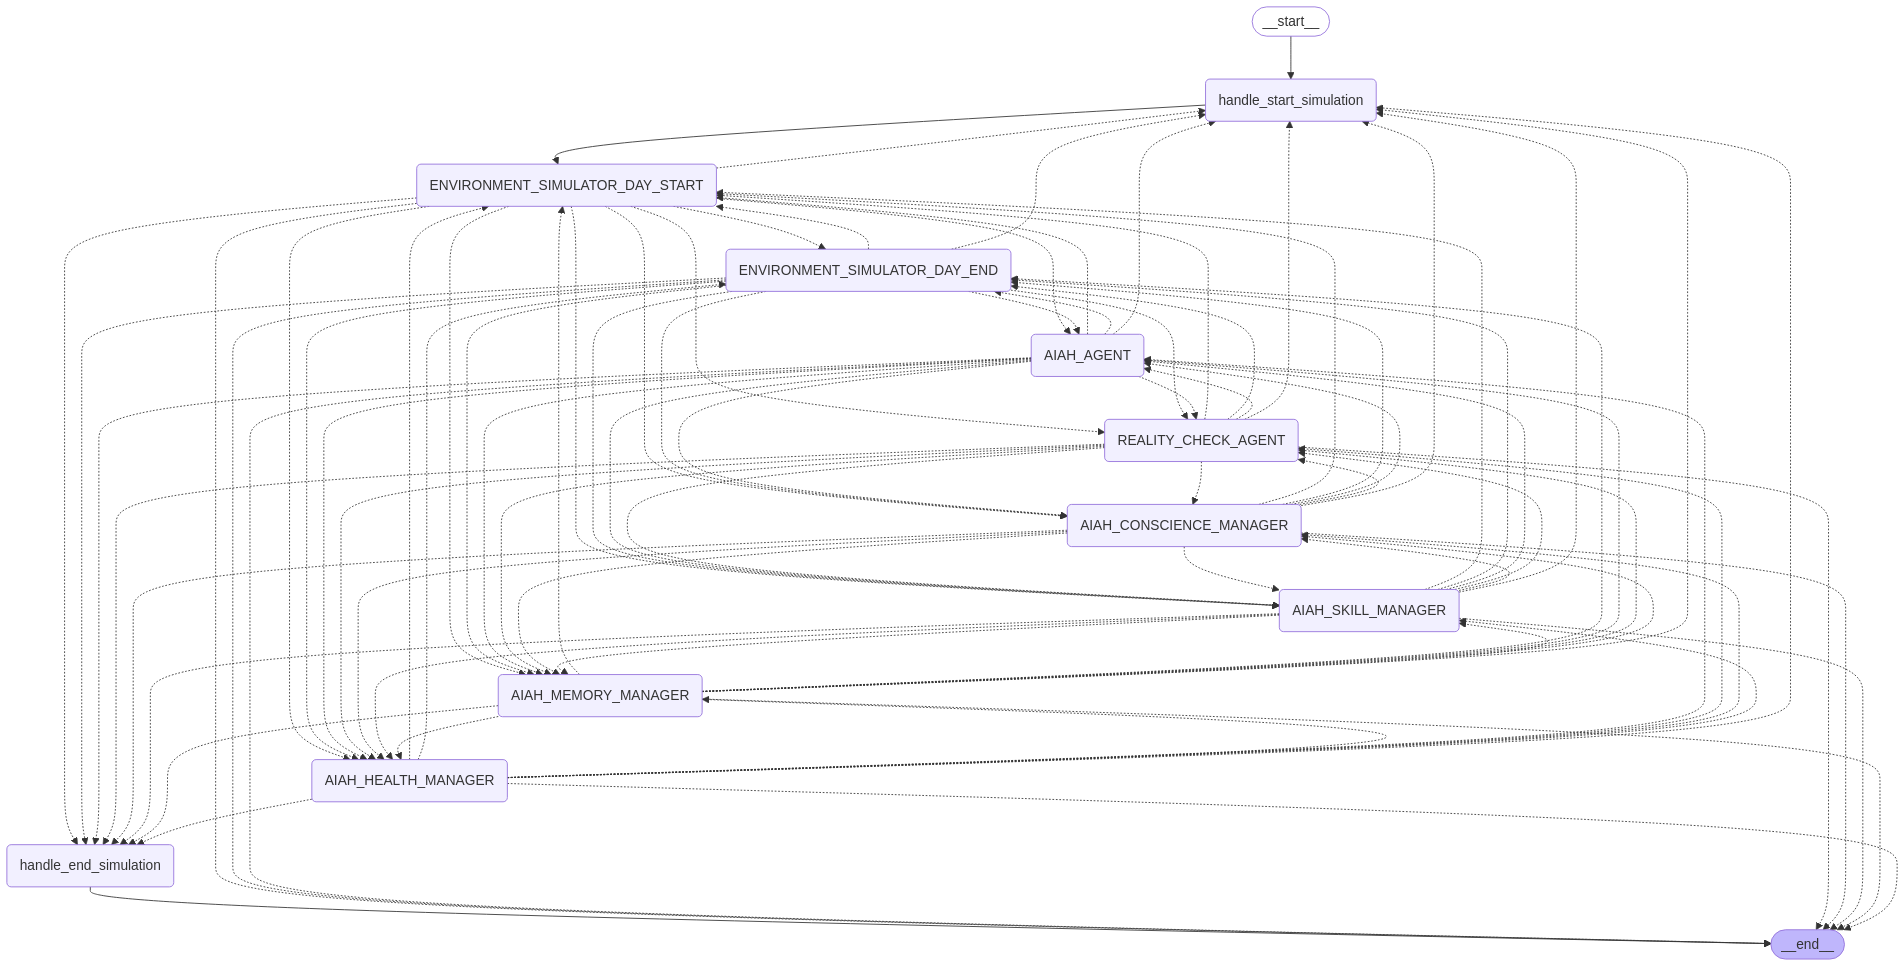

In [174]:
from IPython.display import Image, display


display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
simulation = app.invoke({'previous_agent': None,'current_agent': None,'state_metadata':  {},'day_luck_factor':  8, 'simulation_day_count': 1, 'simulation_total_count':3})

Starting Simulation with Properties: {'previous_agent': None, 'current_agent': None, 'state_metadata': {}, 'simulation_day_count': 1, 'day_luck_factor': 8}
Current State: {'previous_agent': 'ENVIRONMENT_SIMULATOR_DAY_START', 'current_agent': None, 'state_metadata': {'AIAH_prompt_from_ES': 'prompt', 'Day_Environment_Pre_Action': {}}, 'simulation_day_count': 1, 'day_luck_factor': 8}


KeyError: 'possibility'

In [ ]:
simulation

{'previous_agent': None,
 'current_agent': None,
 'state_metadata': {},
 'day_luck_factor': None}